# Instrução do Projeto

A Film Junky Union, uma nova comunidade para entusiastas de filmes clássicos, está desenvolvendo um sistema para filtrar e categorizar resenhas de filmes. O objetivo é treinar um modelo para detectar automaticamente resenhas negativas. Você usará um conjunto de dados de resenhas de filmes do IMDB com rotulagem de polaridade para criar um modelo para classificar resenhas como positivas e negativas. Ele precisará ter um valor F1 de pelo menos 0,85.

## Inicialização

In [1]:
import os
import re

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

import nltk
from nltk.corpus import stopwords as nltk_stopwords

import spacy

import sklearn.metrics as metrics
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from lightgbm import LGBMClassifier

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'

# o estilo 'seaborn' foi renomeado nas versões novas do matplotlib, então tento o nome
# atual e caio no padrão caso nenhum dos dois exista
try:
    plt.style.use('seaborn-v0_8')
except (OSError, ValueError):
    plt.style.use('default')

plt.rcParams['figure.figsize'] = (12, 5)

tqdm.pandas()

## Carregar os dados

O mesmo caminho precisa funcionar tanto na plataforma quanto na minha máquina, então
verifico antes se a pasta `/datasets` existe.

In [3]:
caminho = '/datasets/imdb_reviews.tsv' if os.path.exists('/datasets/imdb_reviews.tsv') else 'imdb_reviews.tsv'
df_reviews = pd.read_csv(caminho, sep='\t', dtype={'votes': 'Int64'})

df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

In [4]:
df_reviews.head()

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


São 47331 resenhas e 17 colunas. Para a classificação interessam três delas: `review` com
o texto, `pos` com o rótulo de polaridade e `ds_part` com a divisão entre treino e teste.
As outras descrevem o filme e vão servir só para a análise exploratória.

Aparecem 2 valores ausentes em `average_rating` e 2 em `votes`. Como essas colunas não
entram no modelo, não vou tratá-las.

In [5]:
print('Resenhas com texto duplicado:', df_reviews['review'].duplicated().sum())
print('Proporção do total: {:.2f}%'.format(df_reviews['review'].duplicated().mean() * 100))
print('Resenhas vazias:', (df_reviews['review'].str.strip() == '').sum())

duplicadas = df_reviews[df_reviews['review'].duplicated(keep=False)]
grupos = duplicadas.groupby('review')
print()
print('Linhas envolvidas nas repetições:', len(duplicadas))
print('Grupos com polaridades conflitantes:', (grupos['pos'].nunique() > 1).sum())
print('Grupos que aparecem no treino e no teste ao mesmo tempo:', (grupos['ds_part'].nunique() > 1).sum())

duplicadas.sort_values('review')[['tconst', 'primary_title', 'rating', 'pos', 'ds_part']].head(6)

Resenhas com texto duplicado: 91
Proporção do total: 0.19%
Resenhas vazias: 0

Linhas envolvidas nas repetições: 173
Grupos com polaridades conflitantes: 0
Grupos que aparecem no treino e no teste ao mesmo tempo: 1


,tconst,primary_title,rating,pos,ds_part
33040,tt0145503,Sunshine,2,0,train
33041,tt0145503,Sunshine,2,0,train
36174,tt0082252,The Decline of Western Civilization,10,1,test
36175,tt0082252,The Decline of Western Civilization,10,1,test
36803,tt0436295,The Fall of Fujimori,1,0,test
36804,tt0436295,The Fall of Fujimori,1,0,test


Existem 91 textos repetidos, o que envolve 173 linhas e representa 0.19% da base. Olhando
as linhas, são cópias da mesma resenha do mesmo filme e com a mesma polaridade, e nenhum
grupo tem rótulos conflitantes.

Só um desses grupos aparece ao mesmo tempo no treino e no teste, então o risco de o modelo
ver no teste um texto que já viu no treino é praticamente nulo. Por isso mantive todas as
linhas.

Nenhuma resenha está vazia.

## Análise exploratória

Começo com um resumo numérico da cobertura da base.

In [6]:
print('Anos de lançamento: de', df_reviews['start_year'].min(), 'a', df_reviews['start_year'].max())
print('Resenhas de filmes de 1990 em diante: {:.1f}%'.format((df_reviews['start_year'] >= 1990).mean() * 100))

resenhas_por_filme = df_reviews.groupby('tconst')['review'].count()
print('Resenhas por filme: mediana {:.0f}, média {:.2f}, máximo {}'.format(
    resenhas_por_filme.median(), resenhas_por_filme.mean(), resenhas_por_filme.max()))
print('Notas presentes na coluna rating:', sorted(df_reviews['rating'].unique().tolist()))

Anos de lançamento: de 1894 a 2010
Resenhas de filmes de 1990 em diante: 64.8%
Resenhas por filme: mediana 4, média 7.12, máximo 30
Notas presentes na coluna rating: [1, 2, 3, 4, 7, 8, 9, 10]


A base cobre de 1894 a 2010, mas 64.8% das resenhas são de filmes de 1990 em diante. Cada
filme tem 4 resenhas na mediana e no máximo 30, então nenhum título domina o vocabulário.

A coluna `rating` só tem notas de 1 a 4 e de 7 a 10. Quem montou a base descartou a faixa
do meio de propósito, para deixar só resenhas claramente negativas ou claramente positivas.

Agora os gráficos, começando por quantos filmes e quantas resenhas existem por ano.

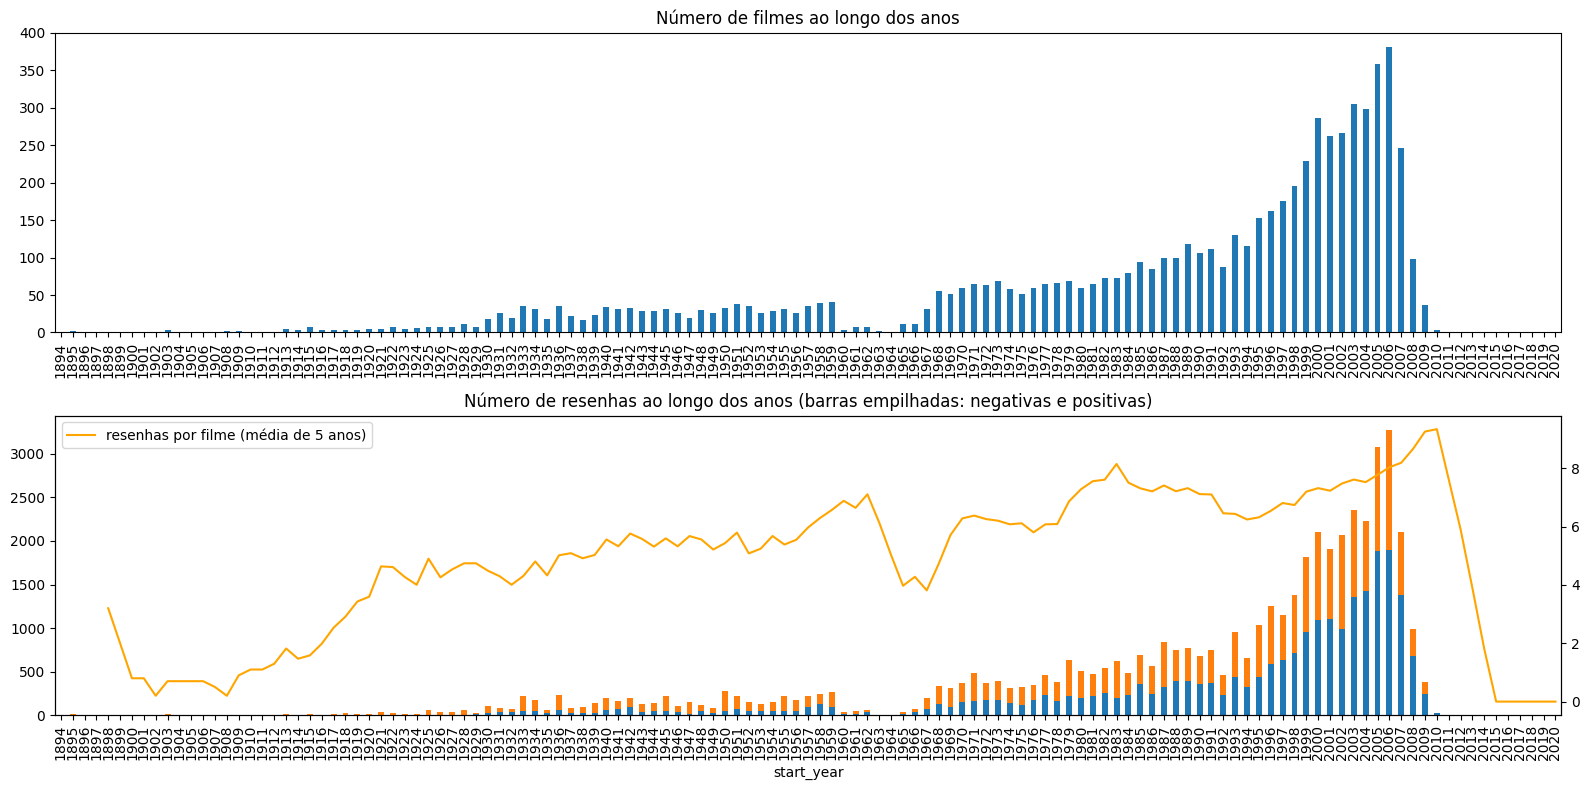

In [7]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates()['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Número de filmes ao longo dos anos')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft2.plot(kind='bar', stacked=True, ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2 / dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(
    color='orange', label='resenhas por filme (média de 5 anos)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Número de resenhas ao longo dos anos (barras empilhadas: negativas e positivas)')

fig.tight_layout()

Os dois gráficos confirmam a concentração no período recente. Filmes anteriores aos anos
1990 aparecem em pequena quantidade e com poucas resenhas cada.

A linha laranja é a média móvel de resenhas por filme. Ela sobe no final do período, o que
faz sentido porque filmes mais recentes recebem mais avaliações no site.

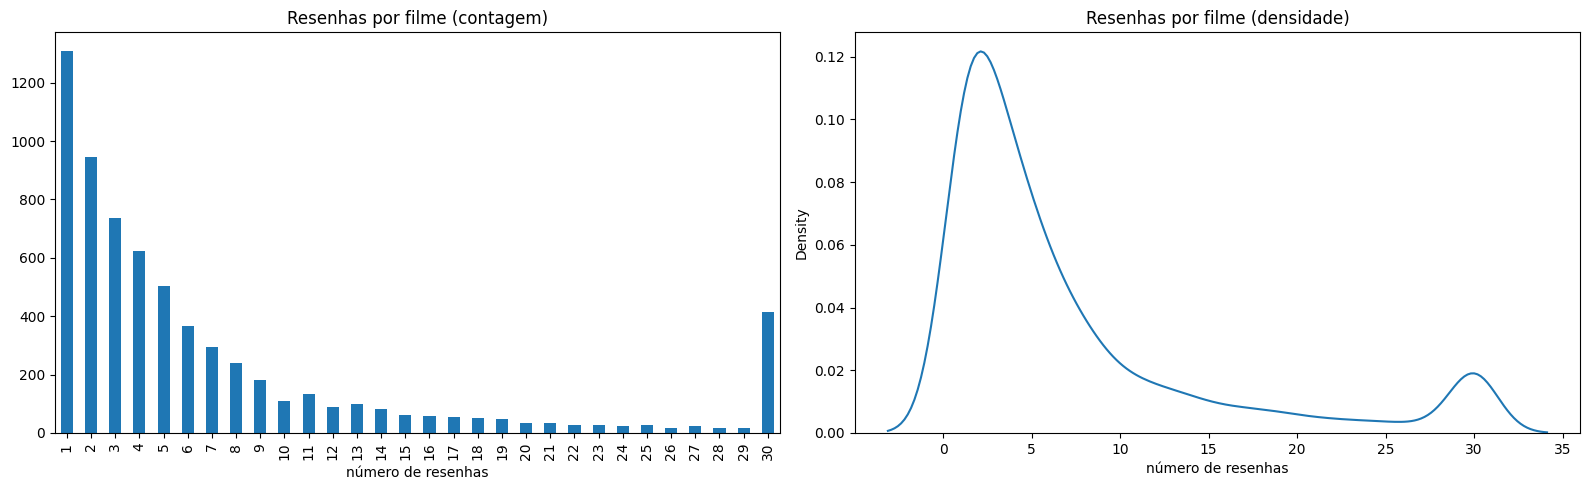

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = resenhas_por_filme.value_counts().sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Resenhas por filme (contagem)')
ax.set_xlabel('número de resenhas')

ax = axs[1]
sns.kdeplot(resenhas_por_filme, ax=ax)
ax.set_title('Resenhas por filme (densidade)')
ax.set_xlabel('número de resenhas')

fig.tight_layout()

A maior parte dos filmes tem poucas resenhas e a cauda vai só até 30. Isso é bom para o
modelo, porque o vocabulário não fica dominado por um punhado de títulos populares.

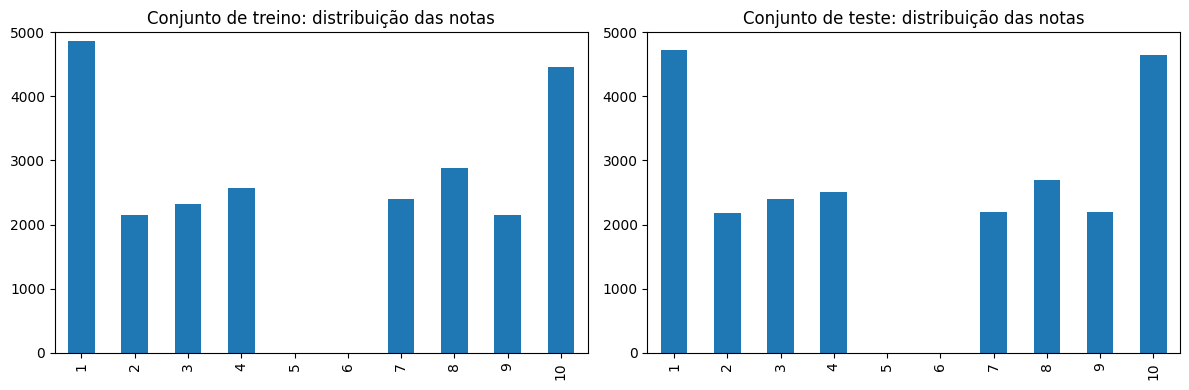

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('Conjunto de treino: distribuição das notas')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('Conjunto de teste: distribuição das notas')

fig.tight_layout()

Treino e teste têm distribuições de nota muito parecidas, com as barras vazias no 5 e no 6
que já apareceram no resumo acima. Nada indica que uma das partes seja mais difícil que a
outra.

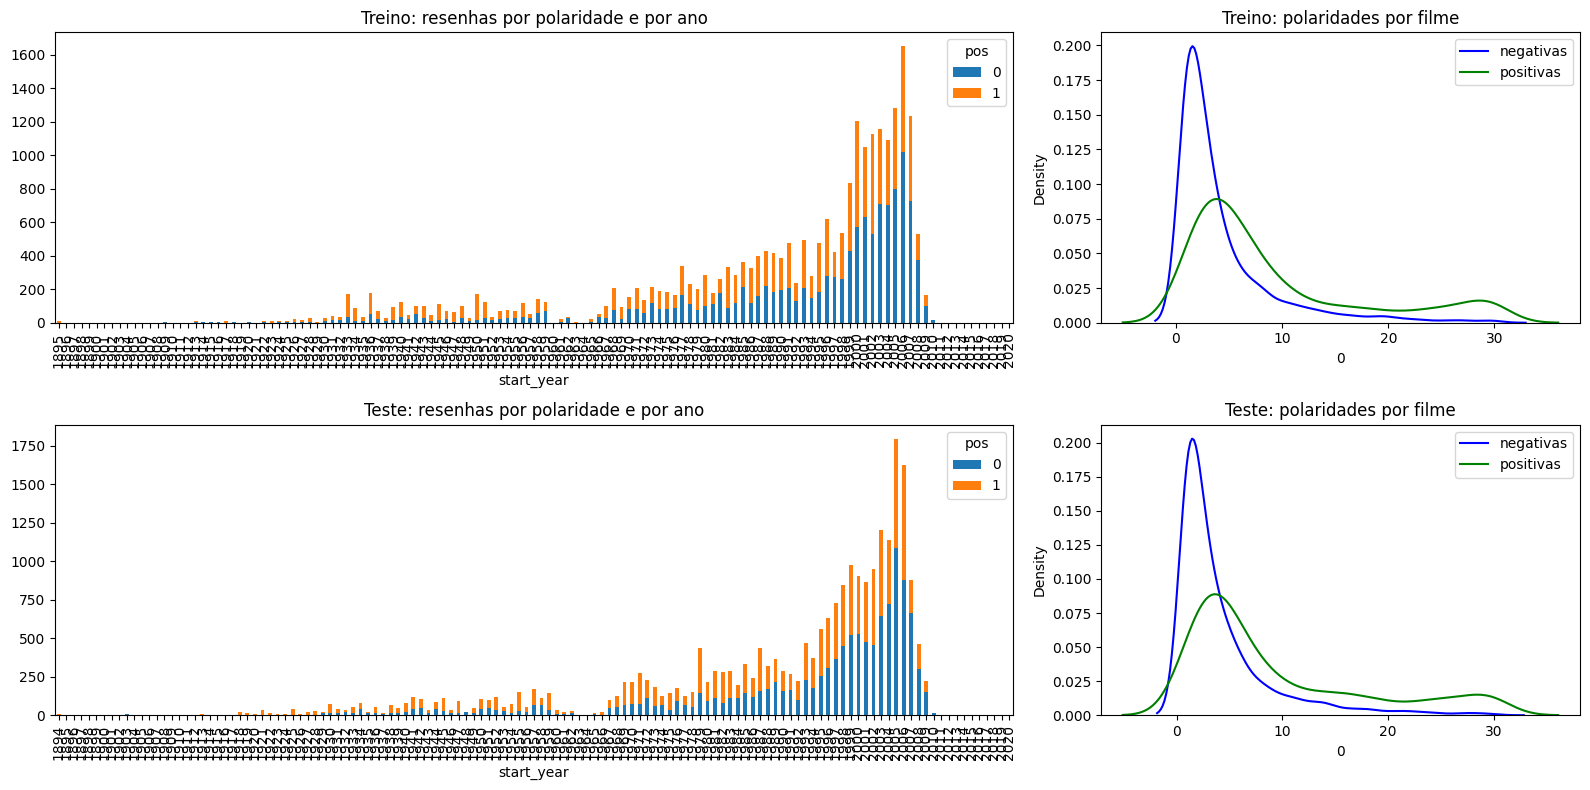

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]
dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2021))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Treino: resenhas por polaridade e por ano')

ax = axs[0][1]
dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negativas', ax=ax)
sns.kdeplot(dft[1], color='green', label='positivas', ax=ax)
ax.legend()
ax.set_title('Treino: polaridades por filme')

ax = axs[1][0]
dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2021))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Teste: resenhas por polaridade e por ano')

ax = axs[1][1]
dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negativas', ax=ax)
sns.kdeplot(dft[1], color='green', label='positivas', ax=ax)
ax.legend()
ax.set_title('Teste: polaridades por filme')

fig.tight_layout()

Treino e teste se comportam do mesmo jeito ao longo dos anos e por filme. As duas
polaridades aparecem misturadas no período todo, sem nenhum ano dominado por um só tipo de
resenha, e as duas curvas de densidade quase se sobrepõem.

Falta confirmar o equilíbrio entre as classes com os números.

In [11]:
contagem = df_reviews.groupby('ds_part')['pos'].value_counts().unstack()
contagem.columns = ['negativas', 'positivas']
contagem['total'] = contagem.sum(axis=1)
contagem['% positivas'] = (contagem['positivas'] / contagem['total'] * 100).round(1)

print(contagem)

         negativas  positivas  total  % positivas
ds_part                                          
test         11803      11732  23535         49.8
train        11912      11884  23796         49.9


As duas partes ficam praticamente com metade de cada classe: 49.9% de positivas no treino
e 49.8% no teste. Não existe desequilíbrio de classe aqui, então dá para treinar sem pesos
de classe e usar o limiar padrão de 0.5 sem ajuste.

Fechando a análise exploratória: a base está limpa para o que preciso, nenhuma resenha
está vazia, treino e teste têm a mesma cara e as classes estão balanceadas. Posso seguir
para o pré-processamento do texto.

## Procedimento de avaliação

Para comparar os modelos de forma justa, monto uma função única que recebe o modelo
treinado e devolve sempre as mesmas métricas e os mesmos gráficos: o F1 em função do
limiar, a curva ROC e a curva de precisão contra revocação.

A função também retorna a tabela de métricas, para eu juntar tudo numa comparação final
no fim do notebook sem precisar recalcular nada.

In [12]:
def evaluate_model(model, train_features, train_target, test_features, test_target):

    eval_stats = {}

    fig, axs = plt.subplots(1, 3, figsize=(20, 6))

    for tipo, features, target in (('treino', train_features, train_target),
                                   ('teste', test_features, test_target)):

        eval_stats[tipo] = {}

        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]

        # F1 em função do limiar
        f1_thresholds = np.arange(0, 1.01, 0.05)
        # zero_division=0 porque em limiares altos o modelo constante não prevê nenhuma
        # resenha positiva e o F1 ficaria indefinido
        f1_scores = [metrics.f1_score(target, pred_proba >= threshold, zero_division=0)
                     for threshold in f1_thresholds]

        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)
        eval_stats[tipo]['ROC AUC'] = roc_auc

        # curva de precisão x revocação
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[tipo]['APS'] = aps

        color = 'blue' if tipo == 'treino' else 'green'

        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color,
                label=f'{tipo}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds - threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx],
                    color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('limiar')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title('F1 por limiar')

        ax = axs[1]
        ax.plot(fpr, tpr, color=color, label=f'{tipo}, ROC AUC={roc_auc:.2f}')
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds - threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx],
                    color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')
        ax.set_title('Curva ROC')

        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{tipo}, AP={aps:.2f}')
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds - threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx],
                    color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('revocação')
        ax.set_ylabel('precisão')
        ax.legend(loc='lower center')
        ax.set_title('Curva PR')

        eval_stats[tipo]['Acurácia'] = metrics.accuracy_score(target, pred_target)
        eval_stats[tipo]['F1'] = metrics.f1_score(target, pred_target, zero_division=0)

    fig.tight_layout()
    plt.show()

    df_eval_stats = pd.DataFrame(eval_stats).reindex(index=('Acurácia', 'F1', 'APS', 'ROC AUC'))
    print(df_eval_stats.round(2))

    return df_eval_stats


# guarda o F1 de teste de cada modelo para a tabela de conclusões
resultados = {}

## Normalização

O texto vem cru, com pontuação, marcação de HTML e maiúsculas. Deixo tudo em minúsculas e
guardo só letras, apóstrofo e espaço. O apóstrofo fica porque separa formas como `don't`
de `dont` e mantém as contrações consistentes.

Depois de trocar o resto por espaço, junto os espaços repetidos com `split` e `join`.

In [13]:
def normalizar(texto):
    texto = str(texto).lower()
    texto = re.sub(r"[^a-z' ]", ' ', texto)
    return ' '.join(texto.split())


df_reviews['review_norm'] = df_reviews['review'].apply(normalizar)

df_reviews[['review', 'review_norm']].head(3)

,review,review_norm
0,The pakage implies that Warren Beatty and Gold...,the pakage implies that warren beatty and gold...
1,How the hell did they get this made?! Presenti...,how the hell did they get this made presenting...
2,There is no real story the film seems more lik...,there is no real story the film seems more lik...


## Divisão treino / teste

A divisão já vem pronta na coluna `ds_part`, então só preciso separar os dois blocos.

In [14]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 18)
(23535, 18)


## Trabalhando com os modelos

### Modelo 0: classificador constante

Serve de linha de base. Ele prevê sempre a classe mais frequente, que aqui é a negativa,
então nunca acerta uma resenha positiva.

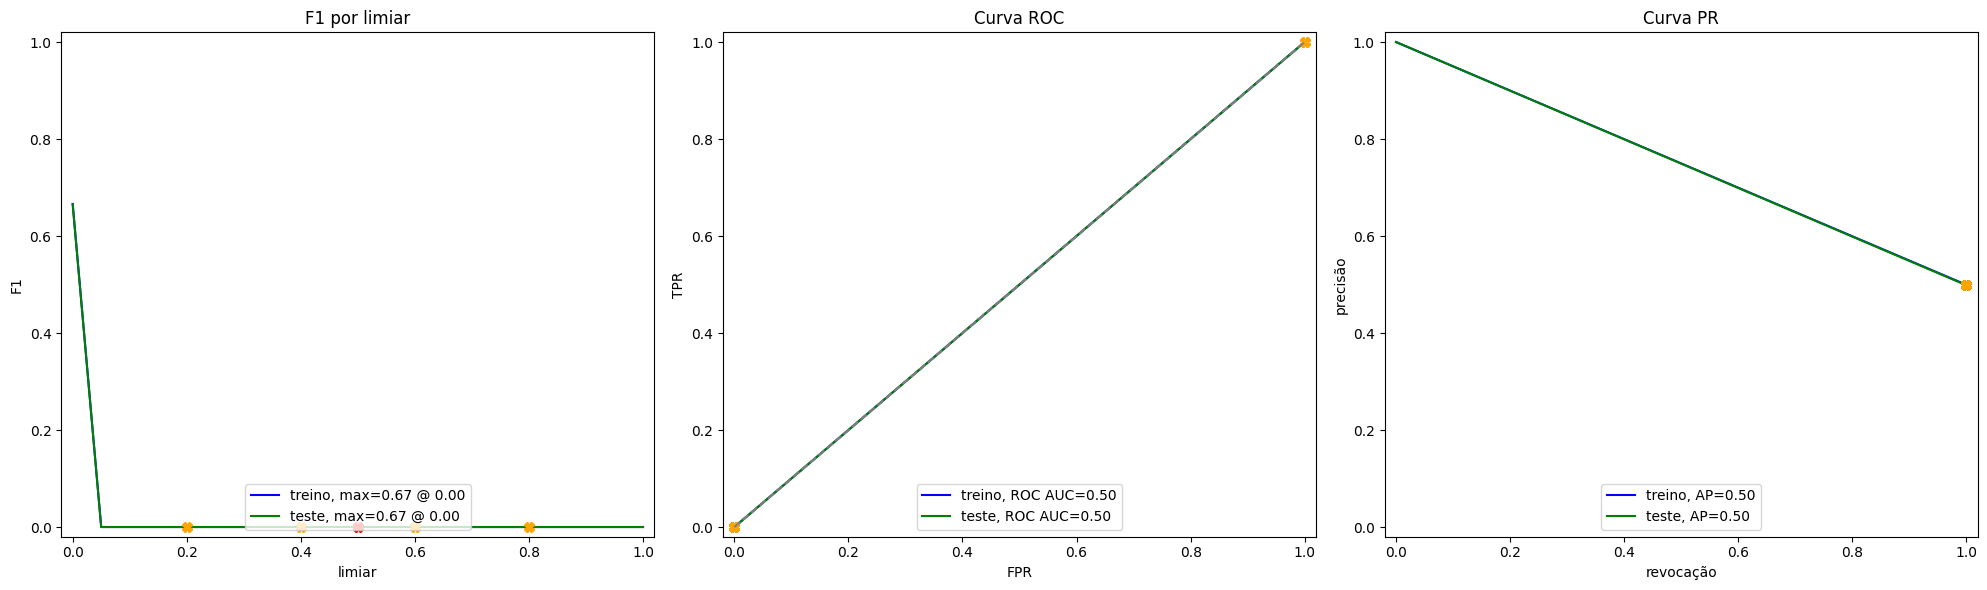

          treino  teste
Acurácia     0.5    0.5
F1           0.0    0.0
APS          0.5    0.5
ROC AUC      0.5    0.5


In [15]:
modelo_0 = DummyClassifier(strategy='most_frequent')
modelo_0.fit(df_reviews_train['review_norm'], train_target)

stats_0 = evaluate_model(modelo_0, df_reviews_train['review_norm'], train_target,
                         df_reviews_test['review_norm'], test_target)
resultados['Modelo 0: constante'] = stats_0.loc['F1', 'teste']

F1 igual a 0 nos dois conjuntos e ROC AUC de 0.5, que é o valor de um modelo sem nenhuma
capacidade de separar as classes. Esse é o piso que os próximos modelos precisam superar.

### Modelo 1: NLTK, TF-IDF e regressão logística

Primeiro modelo de verdade. Uso as stopwords em inglês do NLTK e transformo o texto
normalizado em vetores TF-IDF.

In [16]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/student/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [17]:
# o tokenizador padrão do TfidfVectorizer descarta apóstrofos e palavras de uma letra só,
# então passo as stopwords pelo mesmo tokenizador para a lista ficar consistente com o que
# o vetorizador realmente produz
analisador = TfidfVectorizer().build_analyzer()
stop_words = sorted({token for palavra in nltk_stopwords.words('english') for token in analisador(palavra)})

print('Quantidade de stopwords:', len(stop_words))
print(stop_words[:15])

Quantidade de stopwords: 145
['about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', 'as', 'at']


In [18]:
%%time
tfidf_1 = TfidfVectorizer(stop_words=stop_words)
train_features_1 = tfidf_1.fit_transform(df_reviews_train['review_norm'])
test_features_1 = tfidf_1.transform(df_reviews_test['review_norm'])

print('Formato da matriz de treino:', train_features_1.shape)

modelo_1 = LogisticRegression(solver='liblinear', C=1, random_state=12345)
modelo_1.fit(train_features_1, train_target)

Formato da matriz de treino: (23796, 71531)
CPU times: user 5.39 s, sys: 2.91 s, total: 8.29 s
Wall time: 6.62 s


LogisticRegression(C=1, random_state=12345, solver='liblinear')

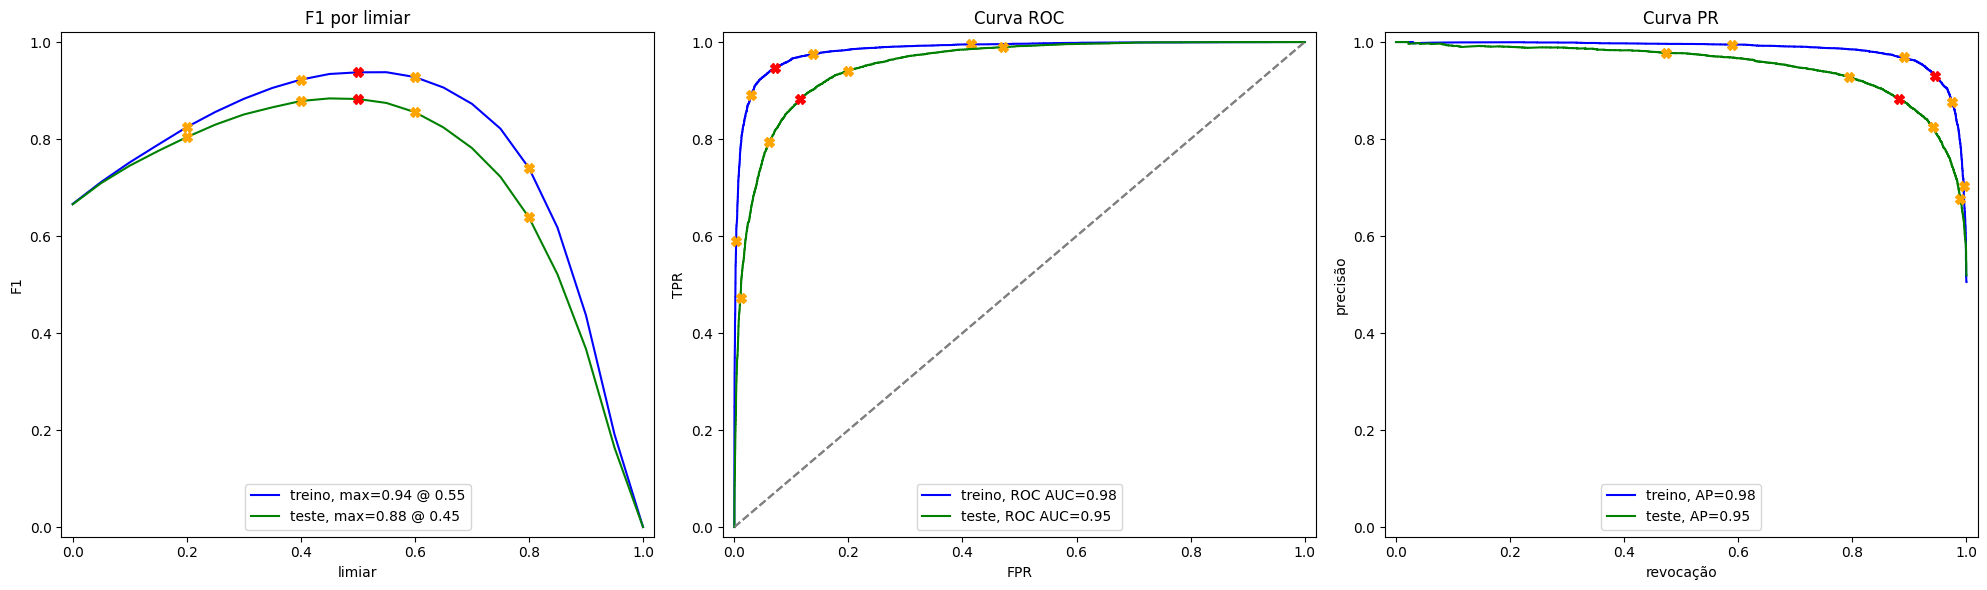

          treino  teste
Acurácia    0.94   0.88
F1          0.94   0.88
APS         0.98   0.95
ROC AUC     0.98   0.95


In [19]:
stats_1 = evaluate_model(modelo_1, train_features_1, train_target, test_features_1, test_target)
resultados['Modelo 1: TF-IDF + LR'] = stats_1.loc['F1', 'teste']

A matriz de treino ficou com 71531 termos. O F1 no teste deu 0.88 contra 0.94 no treino,
uma diferença que existe mas não chega a ser preocupante, e o ROC AUC de 0.95 no teste
mostra que o modelo separa bem as duas classes.

Esse primeiro modelo já passa da meta de 0.85, e o tempo de treino ficou na casa dos
segundos.

### Modelo 3: spaCy, TF-IDF e regressão logística

Agora acrescento a lematização com o spaCy antes de vetorizar. A ideia é reduzir formas
diferentes da mesma palavra a um único token e com isso diminuir o vocabulário.

Desligo o `parser` e o `ner` porque só preciso dos lemas, e processo em lote com
`nlp.pipe`. Mesmo assim é a etapa mais cara do notebook, então salvo o resultado em
`lemm_cache.tsv` e reaproveito nas execuções seguintes. Nesta execução, gerar os lemas das 47331 resenhas levou cerca de 6 minutos. Como o resultado
fica salvo em `lemm_cache.tsv`, as execuções seguintes apenas releem esse arquivo, que é o
tempo que aparece na célula abaixo.

In [20]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])


def lematizar(textos):
    # o spaCy paraleliza com multiprocessing, que não funciona dentro do notebook no
    # Windows; e para poucos textos abrir processos extras só atrasa
    n_process = 4 if (os.name != 'nt' and len(textos) > 1000) else 1
    docs = nlp.pipe(textos, batch_size=64, n_process=n_process)
    return [' '.join(token.lemma_ for token in doc)
            for doc in tqdm(docs, total=len(textos), disable=len(textos) < 1000)]

In [21]:
%%time
arquivo_cache = 'lemm_cache.tsv'

if os.path.exists(arquivo_cache):
    cache = pd.read_csv(arquivo_cache, sep='\t', keep_default_na=False)
    df_reviews['review_lemm'] = cache['review_lemm'].values
    print('Lemas carregados de', arquivo_cache)
else:
    df_reviews['review_lemm'] = lematizar(df_reviews['review_norm'].tolist())
    df_reviews[['review_lemm']].to_csv(arquivo_cache, sep='\t', index=False)
    print('Lemas gerados e salvos em', arquivo_cache)

df_reviews_train['review_lemm'] = df_reviews.loc[df_reviews_train.index, 'review_lemm']
df_reviews_test['review_lemm'] = df_reviews.loc[df_reviews_test.index, 'review_lemm']

df_reviews[['review_norm', 'review_lemm']].head(3)

Lemas carregados de lemm_cache.tsv
CPU times: user 357 ms, sys: 60.1 ms, total: 417 ms
Wall time: 417 ms


,review_norm,review_lemm
0,the pakage implies that warren beatty and gold...,the pakage imply that warren beatty and goldie...
1,how the hell did they get this made presenting...,how the hell do they get this make present its...
2,there is no real story the film seems more lik...,there be no real story the film seem more like...


Dá para ver o efeito já nas três primeiras linhas: `implies` virou `imply`, `is` virou
`be`, `seems` virou `seem`.

In [22]:
%%time
tfidf_3 = TfidfVectorizer(stop_words=stop_words)
train_features_3 = tfidf_3.fit_transform(df_reviews_train['review_lemm'])
test_features_3 = tfidf_3.transform(df_reviews_test['review_lemm'])

print('Formato da matriz de treino:', train_features_3.shape)

modelo_3 = LogisticRegression(solver='liblinear', C=1, random_state=12345)
modelo_3.fit(train_features_3, train_target)

Formato da matriz de treino: (23796, 59139)
CPU times: user 5.28 s, sys: 2.78 s, total: 8.06 s
Wall time: 6.42 s


LogisticRegression(C=1, random_state=12345, solver='liblinear')

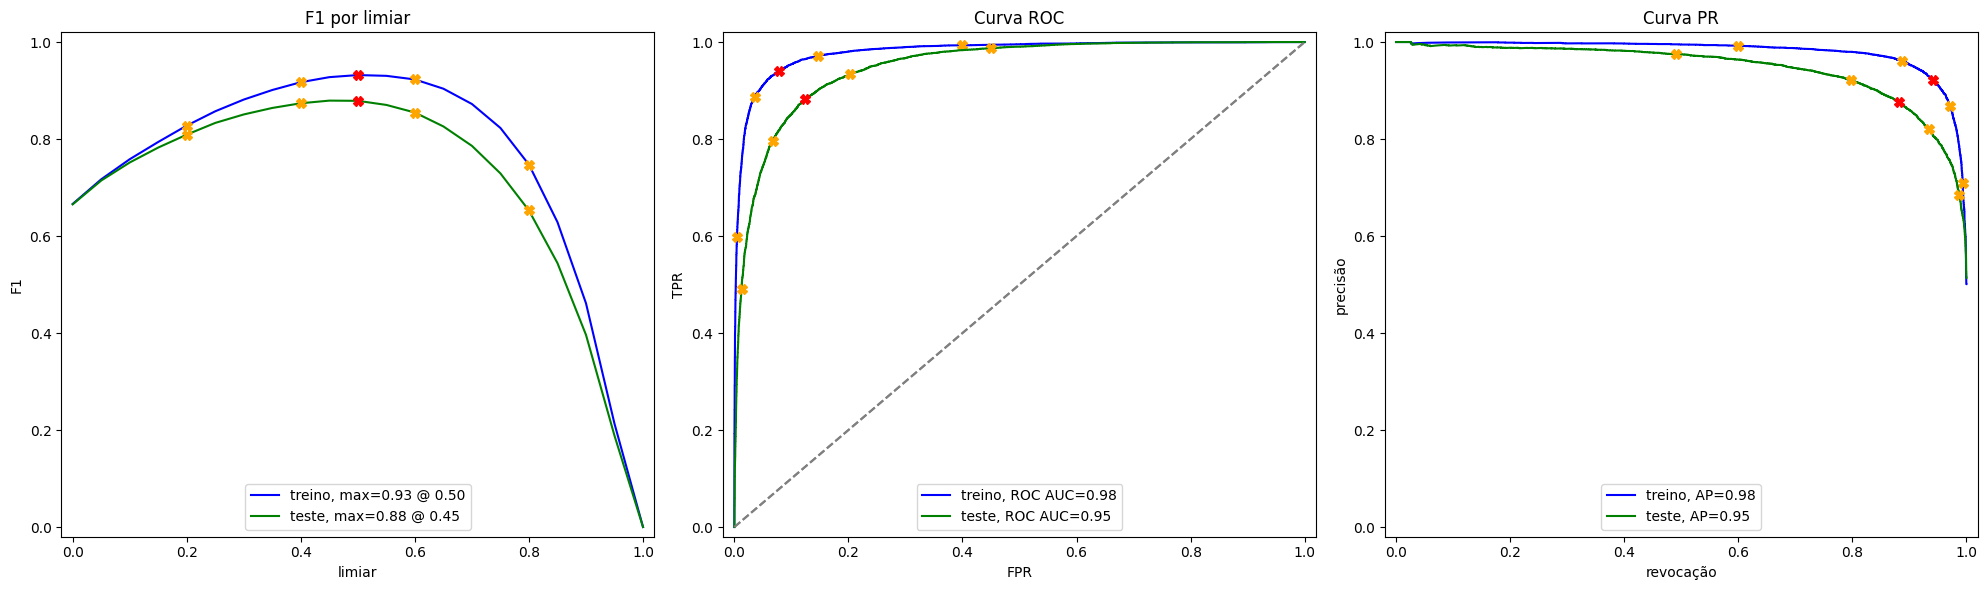

          treino  teste
Acurácia    0.93   0.88
F1          0.93   0.88
APS         0.98   0.95
ROC AUC     0.98   0.95


In [23]:
stats_3 = evaluate_model(modelo_3, train_features_3, train_target, test_features_3, test_target)
resultados['Modelo 3: spaCy + TF-IDF + LR'] = stats_3.loc['F1', 'teste']


A lematização reduziu o vocabulário de 71531 para 59139 termos, cerca de 17% a menos. O F1
no teste ficou em 0.88 na tabela arredondada, mas na comparação final dá para ver que é
0.879 contra 0.883 do modelo anterior.

Ou seja, juntar as formas flexionadas não trouxe ganho. Faz sentido: em análise de
sentimento a flexão às vezes carrega intensidade, e ao colapsar tudo num lema só essa
diferença se perde. O custo, por outro lado, é alto, porque a lematização é a etapa mais
demorada de todo o processo.

### Modelo 4: spaCy, TF-IDF e LightGBM

Mesmo texto lematizado, mas trocando a regressão logística por um gradient boosting.
Limito o vocabulário a 30000 termos porque o LightGBM fica lento demais com a matriz
completa.

In [ ]:
%%time
tfidf_4 = TfidfVectorizer(stop_words=stop_words, max_features=30000)
train_features_4 = tfidf_4.fit_transform(df_reviews_train['review_lemm'])
test_features_4 = tfidf_4.transform(df_reviews_test['review_lemm'])

print('Formato da matriz de treino:', train_features_4.shape)

modelo_4 = LGBMClassifier(n_estimators=200, learning_rate=0.1, random_state=12345, verbose=-1)
modelo_4.fit(train_features_4, train_target)

Formato da matriz de treino: (23796, 30000)


In [ ]:
stats_4 = evaluate_model(modelo_4, train_features_4, train_target, test_features_4, test_target)
resultados['Modelo 4: spaCy + TF-IDF + LGBM'] = stats_4.loc['F1', 'teste']

O LightGBM chegou a 0.96 de F1 no treino contra 0.87 no teste, a maior distância entre os
dois conjuntos dos três modelos. Ele se ajusta bastante ao treino e generaliza um pouco
menos.

Comparando os tempos que aparecem nas células, o treino do LightGBM foi o mais caro dos
três, mesmo com o vocabulário cortado para 30000 termos, e ainda assim o resultado no
teste foi o mais baixo. A troca não compensou.

Isso combina com a natureza do problema: a matriz TF-IDF é muito esparsa e tem dezenas de
milhares de colunas, um cenário em que um modelo linear costuma se sair melhor que um
conjunto de árvores.

### Sobre o BERT

O enunciado deixa o BERT como etapa opcional e avisa que ele precisa de GPU para processar
o conjunto inteiro em tempo razoável, então parei nos quatro modelos acima, que já atingem
a meta pedida.

## Minhas resenhas

Escrevi oito resenhas curtas para ver como os modelos se comportam fora da base. Elas
estão em inglês porque é a língua em que os modelos foram treinados, e o TF-IDF só
reconhece palavras que apareceram no treino.

In [ ]:
my_reviews = pd.DataFrame([
    'I did not simply like it, not my kind of movie.',
    'Well, I was bored and felt asleep in the middle of the movie.',
    'I was really fascinated with the movie',
    'Even the actors looked really old and disinterested, and they got paid to be in the movie. What a soulless cash grab.',
    "I didn't expect the reboot to be so good! Writers really cared about the source material",
    "The movie had its upsides and downsides, but I feel like overall it's a decent flick. I could see myself going to see it again.",
    "What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even kids won't like this!",
    'Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode, of this exciting intelligent new drama.',
], columns=['review'])

my_reviews['review_norm'] = my_reviews['review'].apply(normalizar)
my_reviews['review_lemm'] = lematizar(my_reviews['review_norm'].tolist())

my_reviews[['review_norm', 'review_lemm']]


Lendo as oito, eu classificaria como positivas as de índice 2, 4, 5 e 7 da tabela acima, e
como negativas as de índice 0, 1, 3 e 6. A de índice 5, do "decent flick", é a mais ambígua,
porque fala dos dois lados antes de fechar com um elogio moderado.

In [ ]:
def classificar(coluna_texto, vetorizador, modelo):
    features = vetorizador.transform(my_reviews[coluna_texto])
    return modelo.predict_proba(features)[:, 1]


my_reviews['Modelo 1'] = classificar('review_norm', tfidf_1, modelo_1)
my_reviews['Modelo 3'] = classificar('review_lemm', tfidf_3, modelo_3)
my_reviews['Modelo 4'] = classificar('review_lemm', tfidf_4, modelo_4)

for coluna in ['Modelo 1', 'Modelo 3', 'Modelo 4']:
    print(coluna)
    for probabilidade, texto in zip(my_reviews[coluna], my_reviews['review_norm']):
        print(f'{probabilidade:.2f}:  {texto[:70]}')
    print()

In [ ]:
my_reviews[['review', 'Modelo 1', 'Modelo 3', 'Modelo 4']]


Usando 0.5 como limiar, os modelos 1 e 4 acertam 6 das 8 resenhas, e o modelo 3 acerta 5.

O modelo 1 erra as de índice 4 e 5. O modelo 3 erra essas duas e também a de índice 2, para a
qual devolve 0.49, praticamente em cima do limiar. O modelo 4 acerta a de índice 5, mas erra
as de índice 0 e 4.

A de índice 4 é a única que os três erram juntos, e o motivo é a negação: "I didn't expect the
reboot to be so good" é um elogio, mas o TF-IDF vê "didn't", "expect" e "good" como
palavras soltas e não liga uma na outra. A de índice 5 é justamente a que eu tinha achado
ambígua, e as probabilidades confirmam isso, ficando em 0.47 no modelo 1 e 0.50 no modelo 3.

A de índice 0 mostra o mesmo problema por outro ângulo. Os modelos 1 e 3 acertam por causa de
"not my kind of movie", enquanto o modelo 4 se perde e devolve 0.53.

### E se as resenhas estivessem em português?

Como o vetorizador só conhece o vocabulário do treino, resenhas em outra língua não teriam
como funcionar. Para deixar isso claro, passo as mesmas oito resenhas traduzidas para o
português pelo Modelo 1.

In [ ]:
resenhas_pt = pd.DataFrame([
    'Eu simplesmente não gostei, não é o meu tipo de filme.',
    'Bom, fiquei entediado e dormi no meio do filme.',
    'Fiquei realmente fascinado com o filme',
    'Até os atores pareciam velhos e desinteressados, e ainda foram pagos para estar no filme. Que golpe sem alma.',
    'Eu não esperava que o reboot fosse tão bom! Os roteiristas realmente se importaram com o material original',
    'O filme teve seus altos e baixos, mas no geral acho que é um filme decente. Eu me veria assistindo de novo.',
    'Que tentativa podre de comédia. Nenhuma piada funciona, todo mundo age de forma irritante e barulhenta, nem as crianças vão gostar disso!',
    'Lançar na Netflix foi uma jogada corajosa e eu realmente gosto de poder maratonar episódio após episódio desse novo drama inteligente e empolgante.',
], columns=['review'])

resenhas_pt['review_norm'] = resenhas_pt['review'].apply(normalizar)
features_pt = tfidf_1.transform(resenhas_pt['review_norm'])

termos_reconhecidos = np.asarray((features_pt > 0).sum(axis=1)).ravel()
probabilidades_pt = modelo_1.predict_proba(features_pt)[:, 1]

for n_termos, probabilidade, texto in zip(termos_reconhecidos, probabilidades_pt, resenhas_pt['review']):
    print(f'{n_termos:2d} termos reconhecidos, prob={probabilidade:.2f}:  {texto[:60]}')


Cada resenha em português tem no máximo 11 termos reconhecidos, e boa parte deles é palavra
que existe nas duas línguas por coincidência, como "netflix", "reboot" e "material".

As probabilidades ficam entre 0.46 e 0.76, com metade delas praticamente colada em 0.5, e o
modelo chega a devolver 0.63 para a resenha da comédia ("Que tentativa podre de comédia"),
que é claramente negativa. Sem vocabulário em comum o resultado é quase um sorteio, e é por
isso que as minhas resenhas de teste estão em inglês.

## Comparação entre o conjunto de teste e as minhas resenhas

No conjunto de teste os modelos passam de 0.85 de F1, e nas minhas resenhas eles acertam 5
ou 6 de 8. A diferença não é só de quantidade, é de tipo de texto.

As resenhas do IMDB são longas e repetem vários termos carregados de opinião, então o
TF-IDF acumula bastante evidência a favor de uma das classes e a probabilidade vai para
perto de 0 ou de 1. As minhas têm uma ou duas frases, poucos termos entram na conta e cada
palavra pesa muito, o que empurra as probabilidades para perto do meio.

Minhas resenhas também não citam nomes de filmes, atores ou gênero, que é um tipo de
contexto que aparece bastante no treino e que o modelo acaba usando.

E o ponto principal: como o TF-IDF trata cada palavra isoladamente, ele não captura negação
nem ironia. Foi exatamente aí que os três erraram juntos, na resenha do reboot.

Mesmo assim, os três concordam na direção da maior parte das resenhas, o que mostra que
aprenderam vocabulário de sentimento em vez de decorar os textos do treino.

## Conclusões

In [ ]:
tabela_final = pd.DataFrame({'F1 no teste': pd.Series(resultados)}).round(3)
tabela_final['Meta 0.85'] = np.where(tabela_final['F1 no teste'] >= 0.85, 'atingida', 'não atingida')

tabela_final

Os três modelos de verdade passaram da meta de 0.85 de F1 no teste. O melhor foi o Modelo 1,
com TF-IDF sobre o texto normalizado e regressão logística, em 0.883. Depois vem o Modelo 3,
que acrescenta a lematização do spaCy e fica em 0.879, e por último o Modelo 4 com LightGBM,
em 0.868. O modelo constante serviu de piso, com F1 igual a 0.

O que eu recomendo para a Film Junky Union é o Modelo 1. Ele tem o melhor F1, treina em
poucos segundos e é o mais simples de colocar em produção, porque dispensa a etapa de
lematização, que é de longe a mais demorada do processo. Para um sistema que vai classificar
resenhas novas o tempo todo, essa diferença conta.

A lematização não ajudou aqui. Ela cortou o vocabulário em cerca de 17%, mas junto com isso
apagou distinções que o classificador estava usando, e o F1 caiu um pouco. O LightGBM foi o
que mais se ajustou ao treino, com F1 de 0.96, e o que menos generalizou, com 0.868. Isso
combina com a matriz TF-IDF ser esparsa e ter dezenas de milhares de colunas, um cenário em
que um modelo linear se sai melhor que um conjunto de árvores.

O limite dos três está no próprio TF-IDF, que olha cada palavra isolada e não enxerga
negação nem ironia. Foi exatamente onde eles erraram nas minhas resenhas. Para melhorar a
partir daqui, os caminhos seriam incluir n-gramas de duas ou três palavras no vetorizador,
ou partir para um modelo de linguagem como o BERT, que leva o contexto da frase em conta.

# Checklist


- [x]  O caderno foi aberto
- [x]  Os dados de texto são carregados e pré-processados para vetorização
- [x]  Os dados de texto são transformados em vetores
- [x]  Os modelos são treinados e testados
- [x]  O limiar da métrica foi atingido
- [x]  Todas as células de código estão organizadas na ordem de sua execução
- [x]  Todas as células de código podem ser executadas sem erros
- [x]  Há conclusões 